In [1]:
import os
import pandas as pd
import seaborn as sns

import numpy as np
from matplotlib import pyplot as plt
import scipy

In [10]:
def heatmap(evaluation_results: pd.DataFrame, target_velocities: np.ndarray, delta: float = 0.25):
    evaluation_results_list = evaluation_results.to_dict("records")
    heatmap_values = list()

    for i in range(len(x_positions) - 1):
        for j in range(len(y_positions) - 1):
            heatmap_values.append({
                "x": x_positions[i],
                "y": y_positions[j],
                "r": 0.0
            })

    for i in range(len(heatmap_values)):
        x_min = heatmap_values[i]["x"]
        x_max = x_min + delta

        y_min = heatmap_values[i]["y"]
        y_max = y_min + delta

        rewards = list()
        for j in range(len(evaluation_results_list)):
            x_eval = evaluation_results_list[j]["x_position"]
            y_eval = evaluation_results_list[j]["y_position"]
            r_eval = evaluation_results_list[j]["r"]

            if (x_min <= x_eval < x_max) and (y_min <= y_eval < y_max):
                rewards.append(r_eval)
                pass

        heatmap_values[i]["r"] = np.mean(rewards)
    
    heatmap_values_df = pd.DataFrame.from_dict(heatmap_values)
    heatmap_values_df["x"] = heatmap_values_df["x"] + 0.25
    heatmap_values_df["y"] = heatmap_values_df["y"] + 0.25

    heatmap = heatmap_values_df.pivot(index="y", columns=["x"], values="r")
    heatmap.sort_index(ascending=False, inplace=True)

    return heatmap

In [5]:
def merge_csvs_to_df(csv_paths: list) -> pd.DataFrame:
    merged_data = list()

    for csv in rl_squared_csvs: 
        temp = pd.read_csv(csv).to_dict("records")
        merged_data.extend(temp)
        pass

    return pd.DataFrame.from_records(merged_data)

In [6]:
# constants
grid_size = 3.0
random_seeds = [2878, 5069, 5073, 5250, 4420]

# ranges
x_positions = np.linspace(-grid_size, grid_size, num=13)
y_positions = np.linspace(-grid_size, grid_size, num=13)

In [7]:
rl_squared_csvs = list()
auto_dr_csvs = list()

for seed in random_seeds:
    rl_squared_csvs.append(f"./data/rl_squared/3x3/seed-{seed}.csv")
    auto_dr_csvs.append(f"./data/auto_dr/3x3/seed-{seed}.csv")
    pass

In [8]:
rl_squared_results = merge_csvs_to_df(rl_squared_csvs)

<Axes: xlabel='x', ylabel='y'>

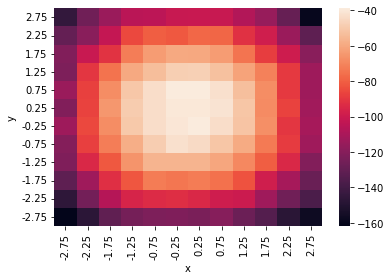

In [11]:
rl_squared_heatmap = heatmap(rl_squared_results, x_positions, y_positions,  0.5)
sns.heatmap(rl_squared_heatmap)

In [ ]:
# @todo plug in the right data sources
auto_dr_results = pd.read_csv("./data/rl_squared/3x3/seed-5069.csv")
auto_dr_heatmap = heatmap(auto_dr_results, x_positions, y_positions,  0.5)
sns.heatmap(auto_dr_heatmap)